In [1]:
from networks.BP_network import *
from networks.DFC_network import *
from src.dataloaders import *
from src.trainers import Trainer, TrainerDFCL, TrainerDFCGen, TrainerCL, TrainerCL_DFC
from src.utils import *
from src.utils import *

/cluster/raid/home/sschwartz/.conda/envs/DFC_project/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
config = {
        "layers": [784, 200, 10],
        "num_classes": 10,
        "lr": 1e-4, 
        "lr_fb": 1e-4, 
        "batch_size": 100,
        "batch_size_gen": 30000,
        "epochs": 50,
        "mode": "di",
        "num_workers": 0,
        "loss_fn": "ce",
        "optimizer": "Adam",
        "scheduler": "CosineAnnealingLR",
        "activation_fun": "Tanh",
        "device": "cuda",
        "output_dir": "./outputs",
        "seed": 1337,
        "taus": [0.02, 0.02, 0.02, 0.016, 0.01],
        "target_lr": 1,#1e-2,       # Updated to optimal value
        "alpha_di": 0.0017,        # 1/tau for tau=0.2
        "dt_di": 0.02,         # Time step
        "time_constant_ratio": 0.2,  # tau
        "tmax_di":2,
        "k_p": 2.0,             # Optimal for G=1, tau=0.2
        "eps": 1e-4,
        "save": True,
        "flatten_imgs": "default",
        "num_tasks": 2,
        "classes_per_task": 5,
        "setting": "classIL5task",
}

config = dotdict(config)

In [3]:
tasks_dataloaders = ClassILMNIST2Task(config=config).get_all_tasks_dataloaders()

In [4]:
# Train model
model = DFCL_network(config=config)

trainer = TrainerCL_DFC(model, tasks_dataloaders, config)
trainer.train()

[DFCL] Feedback connections initialized.
Training:
 - layers: [784, 200, 10]
 - num_classes: 10
 - lr: 0.0001
 - lr_fb: 0.0001
 - batch_size: 100
 - batch_size_gen: 30000
 - epochs: 50
 - mode: di
 - num_workers: 0
 - loss_fn: ce
 - optimizer: Adam
 - scheduler: CosineAnnealingLR
 - activation_fun: Tanh
 - device: cuda
 - output_dir: ./outputs
 - seed: 1337
 - taus: [0.02, 0.02, 0.02, 0.016, 0.01]
 - target_lr: 1
 - alpha_di: 0.0017
 - dt_di: 0.02
 - time_constant_ratio: 0.2
 - tmax_di: 2
 - k_p: 2.0
 - eps: 0.0001
 - save: True
 - flatten_imgs: default
 - num_tasks: 2
 - classes_per_task: 5
 - setting: classIL5task
 - in_channels: 1
 - model: DFCL_network

[TrainerDFCL] Created optimizers: feedforward, 1× feedback.
Starting Task 1/2


				Epoch: 001, Train loss: 1.6587 & test losses: T0: 0.5234 & accuracy: T0: 89.20, Full: 89.16


				Epoch: 002, Train loss: 0.3605 & test losses: T0: 0.1875 & accuracy: T0: 95.76, Full: 95.76


				Epoch: 003, Train loss: 0.1806 & test losses: T0: 0.1233 & accuracy: T0: 96.98, Full: 96.98


				Epoch: 004, Train loss: 0.1324 & test losses: T0: 0.0996 & accuracy: T0: 97.26, Full: 97.26


...

				Epoch: 048, Train loss: 0.0176 & test losses: T0: 0.6167, T1: 0.0625 & accuracy: T0: 78.58, T1: 97.94, Full: 47.61


				Epoch: 049, Train loss: 0.0168 & test losses: T0: 0.6187, T1: 0.0617 & accuracy: T0: 78.07, T1: 97.94, Full: 47.61


				Epoch: 050, Train loss: 0.0159 & test losses: T0: 0.6094, T1: 0.0609 & accuracy: T0: 78.63, T1: 97.90, Full: 47.59
Testing on all seen classes up to Task 2


Testing  epoch 000/50:  66%|██████▌   | 66/100 [00:00<00:00, 653.68batch/s]

Seen Classes - Loss: 5.7228, Accuracy: 47.5900


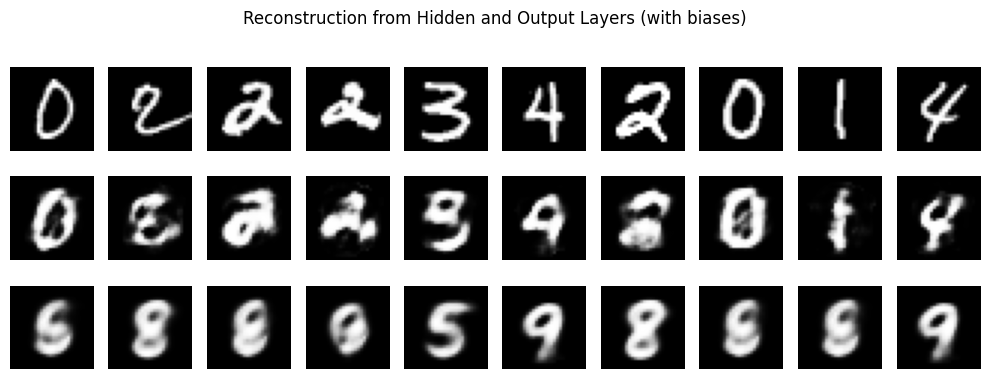

Testing  epoch 000/50: 100%|██████████| 100/100 [00:13<00:00, 653.68batch/s]

In [ ]:
x1, x2, x3 = visualize_reconstructions(model, tasks_dataloaders[0][0])

In [ ]:
(train_loss, train_acc), (test_loss, test_acc) = evaluate(model, tasks_dataloaders[1][0], tasks_dataloaders[1][1], device=model.device)

Train loss: 12.9996 | Train acc: 0.00%
Test  loss: 6.3741 | Test  acc: 50.94%


Testing  epoch 000/50: 100%|██████████| 52/52 [00:10<00:00, 135.41batch/s]

In [13]:
batch_size = 100
num_classes = 10

Xs = []   
Ys = []
Y_preds = []

for batch in tasks_dataloaders[0][0]:
    ypred = model(batch[0].to(model.device))
    B, K = ypred.shape

    target = torch.eye(10).repeat_interleave(int(batch_size/10), dim=0)
    Y_preds.append(target)
    
    Xs.append(batch[0])
    Ys.append(batch[1])   
    if batch_size==100:
        break

X = torch.cat(Xs, dim=0)
Y = torch.cat(Ys, dim=0)
Y_label = torch.argmax(Y,dim=1)
target = torch.cat(Y_preds,dim=0)

print("random targets generated ...")


generated_input2, rs_last = model.generate_samples(target, init_input=X, tmax=5000, threshold=0.001)


random targets generated ...


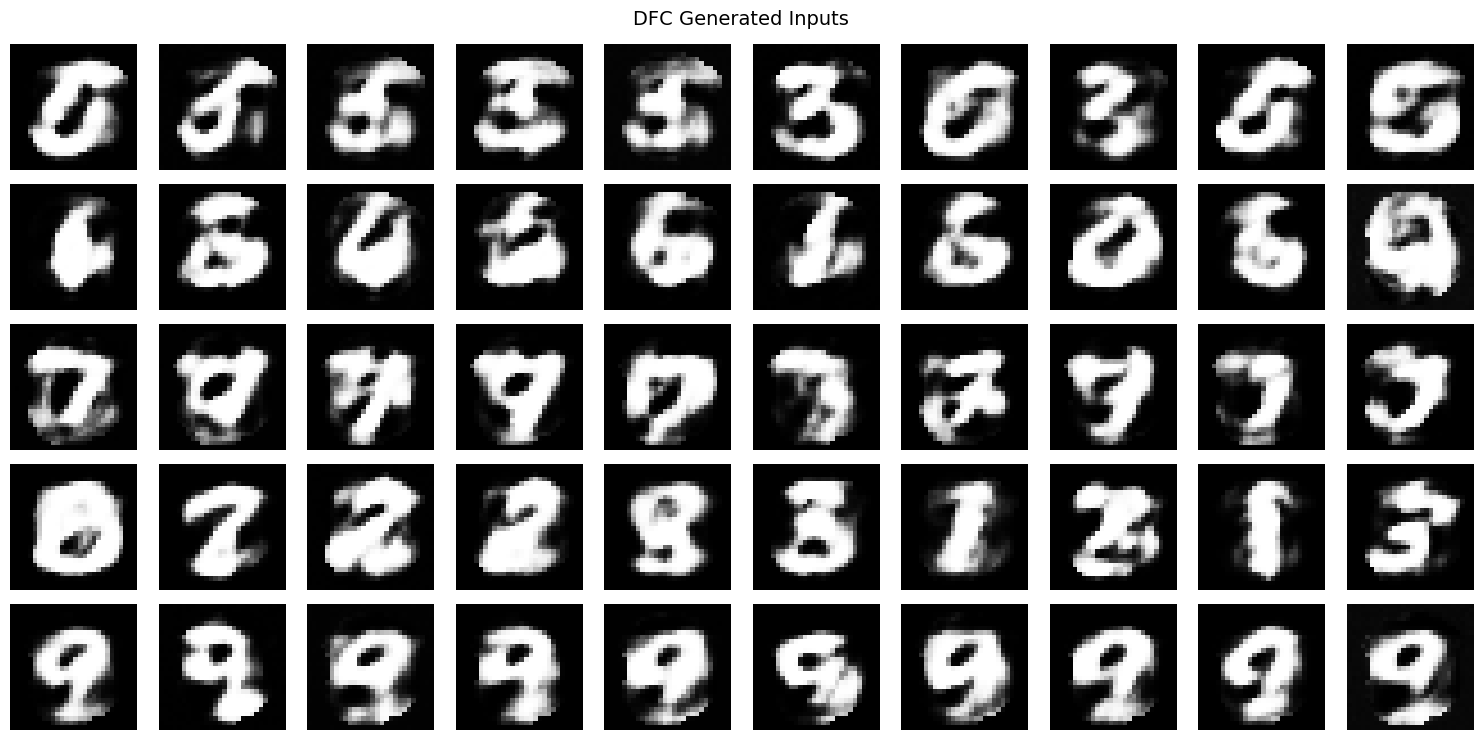

In [14]:
plot_generated_inputs(generated_input2[50:100], n_cols=10, title="DFC Generated Inputs", save=False, filename="Samples_BP_100_epochs.png")